<a href="https://colab.research.google.com/github/AISA-DucHaba/AI-Solution-Architect/blob/main/Rice_Leaf_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leaf Disease Classification
---

- All done using AI coding, default version in Google Colab, Gemini flash 2.5


In [1]:
from datasets import load_dataset

ds = load_dataset("sharmin3/Rice-Leaf-Disease")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/319 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


Rice Leaf Disease-20241115T062818Z-001.z(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7421 [00:00<?, ? examples/s]

In [2]:
type(ds)

datasets.dataset_dict.DatasetDict

In [3]:
# Gemini 2.5 flash
# prompt: display the top 5 row of ds
import pandas as pd

pd.DataFrame(ds['train'][:5])

,image,label
0,<PIL.Image.Image image mode=RGB size=300x300 a...,0
1,<PIL.Image.Image image mode=RGB size=300x300 a...,0
2,<PIL.Image.Image image mode=RGB size=300x300 a...,0
3,<PIL.Image.Image image mode=RGB size=300x300 a...,0
4,<PIL.Image.Image image mode=RGB size=300x300 a...,0


In [4]:
# prompt: convert ds to pandas dataframe and name it leaf_pd
leaf_pd = ds['train'].to_pandas()

In [5]:
leaf_pd.head(3)

,image,label
0,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0
1,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0
2,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0


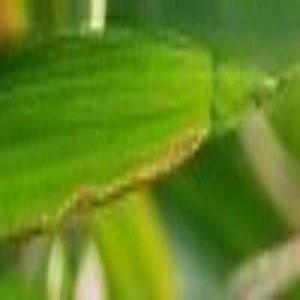

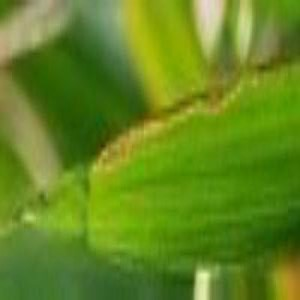

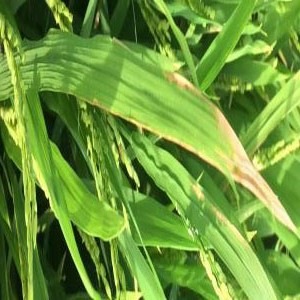

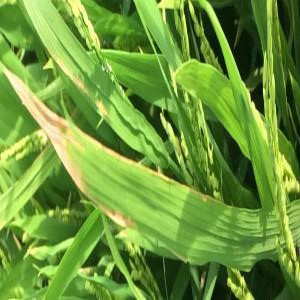

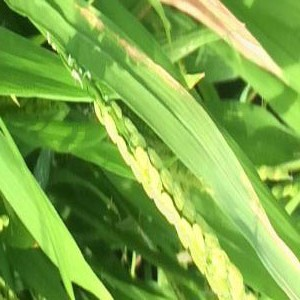

In [6]:
# prompt: display the first five image in the leaf_pd image column
from IPython.display import display

for i in range(5):
    display(ds['train'][i]['image'])

In [7]:
leaf_pd.tail(3)

,image,label
7418,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4
7419,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4
7420,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4


In [8]:
#prompt: from sharmin3/Rice-Leaf-Disease and leaf_pd column label, how to convert the value to type of desease

# Get the label mapping from the dataset's features
label_names = ds['train'].features['label'].names

# Create a dictionary for mapping numerical labels to disease names
label_to_disease = {i: name for i, name in enumerate(label_names)}

# Map the numerical 'label' column to disease names in leaf_pd
leaf_pd['disease_type'] = leaf_pd['label'].map(label_to_disease)

# Display the updated DataFrame with the new 'disease_type' column
display(leaf_pd.head())

,image,label,disease_type
0,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0,Bacterialblight
1,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0,Bacterialblight
2,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0,Bacterialblight
3,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0,Bacterialblight
4,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",0,Bacterialblight


In [9]:
leaf_pd.tail(3)

,image,label,disease_type
7418,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4,Tungro
7419,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4,Tungro
7420,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",4,Tungro


In [10]:
# prompt: show all unique disease_type
unique_disease_types = leaf_pd['disease_type'].unique()
print(unique_disease_types)

['Bacterialblight' 'Blast' 'Brownspot' 'Healthy' 'Tungro']


In [11]:
# prompt: drop the label column in leaf_pd
leaf_pd.drop(columns=['label'], inplace=True)
display(leaf_pd.head())

,image,disease_type
0,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",Bacterialblight
1,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",Bacterialblight
2,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",Bacterialblight
3,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",Bacterialblight
4,"{'bytes': None, 'path': 'zip://Rice Leaf Disea...",Bacterialblight


In [12]:
# prompt: (it as an error so I say) fix this error
# Extract actual PIL Image objects from ds['train'] and add them to leaf_pd
# This is necessary because leaf_pd['image'] currently holds dictionaries, not PIL Image objects directly.
leaf_pd['pil_image_data'] = [item['image'] for item in ds['train']]

In [14]:
# prompt: Export the leaf_pd DataFrame to a CSV file
# index=False prevents pandas from writing the DataFrame index as a column in the CSV.
leaf_pd.to_csv('rice_leaf_data.csv', index=False)
print("DataFrame 'leaf_pd' exported to 'rice_leaf_data.csv'")

DataFrame 'leaf_pd' exported to 'rice_leaf_data.csv'


In [15]:
# Load the previously exported CSV file back into a pandas DataFrame
reloaded_leaf_pd = pd.read_csv('rice_leaf_data.csv')

# Display the first few rows of the reloaded DataFrame to verify
display(reloaded_leaf_pd.head())

,image,disease_type,pil_image_data
0,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_001.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
1,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_002.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
2,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_003.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
3,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_004.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
4,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_005.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>


Now, let's import fastai vision functionalities, define necessary image transformations, and create the `ImageDataLoaders` object.

In [16]:
# prompt: convert the leaf_pd to a fastai data loader object
# prompt: (it has errors so I say ) fix this error
from fastai.vision.all import *

# Define a custom transform to ensure all images are RGB
class ConvertImageToRGB(Transform):
    def encodes(self, o:PILImage):
        if o.mode != 'RGB':
            return o.convert('RGB')
        return o

# Define item transformations (applied to individual images)
# First, ensure all images are RGB, then resize.
item_tfms = [ConvertImageToRGB(), Resize(224)]

# Define batch transformations (applied to batches of images)
# These include data augmentation and normalization.
# `aug_transforms` provides common augmentation techniques.
# `Normalize.from_stats(*imagenet_stats)` normalizes pixel values using ImageNet's mean and standard deviation,
# which is standard for transfer learning with models pre-trained on ImageNet.
batch_tfms = [*aug_transforms(size=224, min_scale=0.75), Normalize.from_stats(*imagenet_stats)]

In [ ]:
# # Extract actual PIL Image objects from ds['train'] and add them to leaf_pd
# # This is necessary because leaf_pd['image'] currently holds dictionaries, not PIL Image objects directly.
# leaf_pd['pil_image_data'] = [item['image'] for item in ds['train']]

In [17]:
leaf_pd.head(3)

,image,disease_type,pil_image_data
0,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_001.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
1,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_002.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>
2,"{'bytes': None, 'path': 'zip://Rice Leaf Disease/Bacterialblight/BACTERAILBLIGHT3_003.jpg::/root/.cache/huggingface/hub/datasets--sharmin3--Rice-Leaf-Disease/snapshots/87d5c7c46c09260cca74b089dec6ef5ee9e8a60d/Rice Leaf Disease-20241115T062818Z-001.zip'}",Bacterialblight,<PIL.Image.Image image mode=RGB size=300x300>


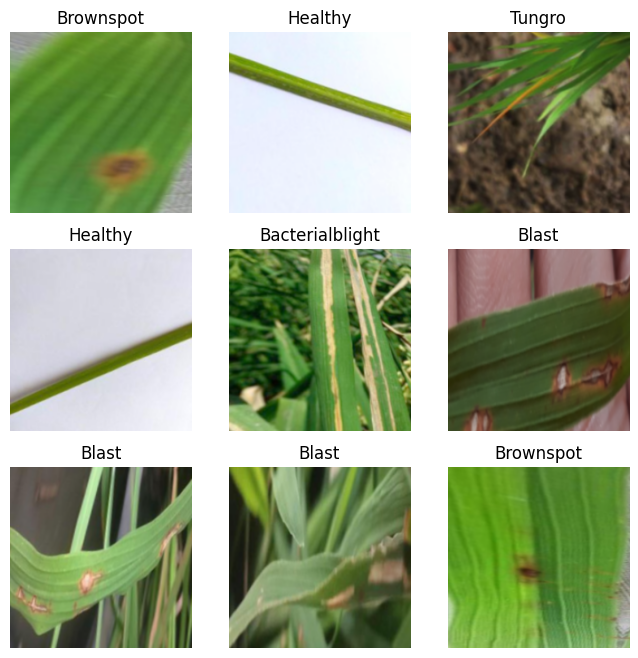

In [18]:
# prompt: convert the leaf_pd to a fastai data loader object
# prompt: (it has errors so I say ) fix this error (3 times, until no more error)
# Define the DataBlock for image classification
rice_leaf_block = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('pil_image_data'),  # Get image from 'pil_image_data' column
    get_y=ColReader('disease_type'),    # Get label from 'disease_type' column
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms
)

# Create the DataLoaders object from the leaf_pd DataFrame using the DataBlock.
dls = rice_leaf_block.dataloaders(leaf_pd, bs=64, num_workers=0)

# Display a batch of images to verify the DataLoader is set up correctly.
dls.show_batch(max_n=9, figsize=(8, 8))

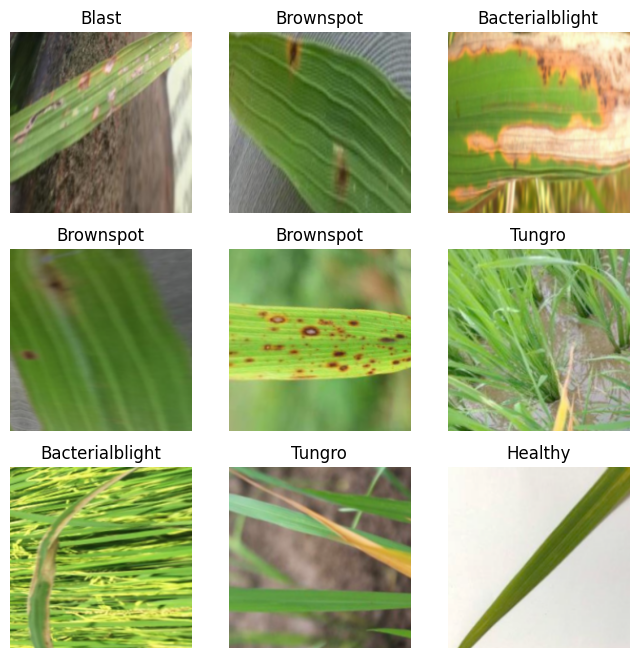

In [22]:
dls.show_batch(max_n=9, figsize=(8, 8))

In [23]:
#prompt: create fastai learner object from dls
# Create a fastai Learner object
# We'll use a pre-trained ResNet34 model, which is common for image classification tasks.
# The `metrics` parameter will track accuracy during training.
learn = cnn_learner(dls, resnet34, metrics=accuracy)

# Display the Learner object to see its structure and parameters
print(learn)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 159MB/s]


<div></div>

SuggestedLRs(valley=0.0006918309954926372)

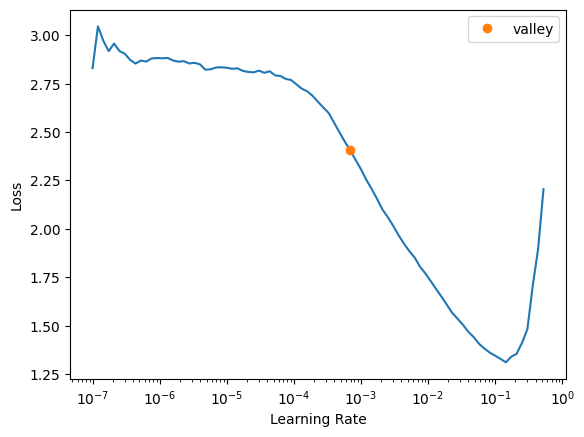

In [24]:
# prompt: find the learning rate
# Use lr_find to determine an optimal learning rate for training
# This method runs a short training sequence, increasing the learning rate at each step,
# and records the loss. The plot helps visualize where the loss decreases most steeply
# and where it starts to diverge.
learn.lr_find()

<div></div>

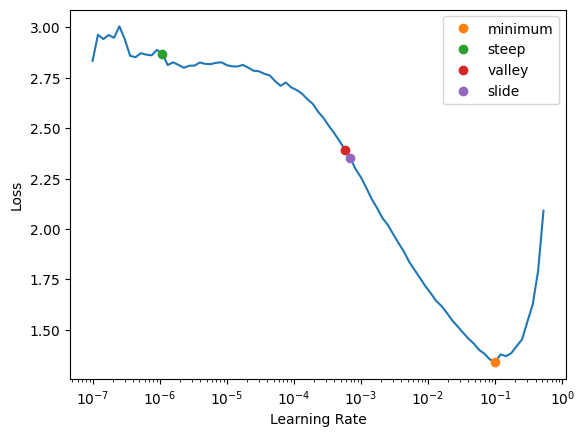

In [26]:
lrates = learn.lr_find(suggest_funcs=(minimum, steep, valley, slide))

In [27]:
lrates.slide

0.0006918309954926372

In [28]:
learn.fine_tune(8, base_lr=lrates.slide)

epoch,train_loss,valid_loss,accuracy,time
0,0.753350,0.188390,0.929245,00:23


epoch,train_loss,valid_loss,accuracy,time
0,0.187292,0.058294,0.977089,00:24
1,0.080779,0.016703,0.994609,00:24
2,0.028439,0.004276,0.997978,00:24
3,0.012146,0.006346,0.997305,00:24
4,0.013219,0.004613,0.997305,00:24
5,0.005149,0.001036,0.999326,00:24
6,0.005545,0.000723,1.000000,00:24
7,0.004012,0.001691,0.999326,00:25


In [29]:
# prompt: export and save foxy.learner

fname = f"./leaf_desease_learner_{int(time.time())}.pkl"
learn.export(fname)
print(fname)

./leaf_desease_learner_1780474400.pkl
